In [1]:
import matplotlib.pyplot as plt
import h5py
import glob
import numpy as np
from matplotlib.colors import LogNorm

In [2]:
MODULE_BOXES = [
    {"io group": 1, "pixel size": 0.443, "xmin":  33.5, "xmax": 63.93, "ymin": -61.85, "ymax": 61.85, "zmin":  2.68,  "zmax": 64.32},
    {"io group": 2, "pixel size": 0.443, "xmin":  3.07, "xmax": 33.5,  "ymin": -61.85, "ymax": 61.85, "zmin":  2.68,  "zmax": 64.32},
    {"io group": 3, "pixel size": 0.443, "xmin":  33.5, "xmax": 63.93, "ymin": -61.85, "ymax": 61.85, "zmin": -64.32, "zmax": -2.68},
    {"io group": 4, "pixel size": 0.443, "xmin":  3.07, "xmax": 33.5,  "ymin": -61.85, "ymax": 61.85, "zmin": -64.32, "zmax": -2.68},
    {"io group": 5, "pixel size": 0.387, "xmin": -33.5, "xmax": -3.07, "ymin": -61.85, "ymax": 61.85, "zmin":  2.68,  "zmax": 64.32},
    {"io group": 6, "pixel size": 0.387, "xmin": -63.93,"xmax": -33.5, "ymin": -61.85, "ymax": 61.85, "zmin":  2.68,  "zmax": 64.32},
    {"io group": 7, "pixel size": 0.4434,"xmin": -33.5, "xmax": -3.07, "ymin": -61.85, "ymax": 61.85, "zmin": -64.32, "zmax": -2.68},
    {"io group": 8, "pixel size": 0.4434,"xmin": -63.93,"xmax": -35.5, "ymin": -61.85, "ymax": 61.85, "zmin": -64.32, "zmax": -2.68}
]

In [3]:
def slice_from_ref_region(dset, ref_region_row):
    start = int(ref_region_row["start"])
    stop  = int(ref_region_row["stop"])
    return dset[start:stop]
def get_event_hits_by_event_index(f, event_index):
    hits = f["charge/calib_prompt_hits/data"]
    rr   = f["charge/events/ref/charge/calib_prompt_hits/ref_region"]
    return slice_from_ref_region(hits, rr[event_index])

In [7]:
y_1, z_1 = [], []
y_2, z_2 = [], []
files = sorted(glob.glob("data/*.FLOW.hdf5"))
for fname in files:
    with h5py.File(fname, "r") as f:
        for evt_idx in range(len(f["charge/events/data"])):
            hits = get_event_hits_by_event_index(f, evt_idx)
            if len(hits) == 0:
                continue
            y = hits['y']
            z = hits['z']
            Q  = hits['Q']  
            mask_1 = np.isfinite(Q) & (Q >= 0) &(z>=-54.32) & (z<=-12.68) & (y>=-51.85) & (y<=51.85) 
            mask_2 = np.isfinite(Q) & (Q >= 0) &(z>=12.68) & (z<=54.32) & (y>=-51.85) & (y<=51.85) 
            if np.any(mask_1):
                y_1.append(y[mask_1])
                z_1.append(z[mask_1])
            if np.any(mask_2):
                y_2.append(y[mask_2])
                z_2.append(z[mask_2])

In [ ]:
y_1 = np.concatenate(y_1)
z_1 = np.concatenate(z_1)
y_2 = np.concatenate(y_2)
z_2 = np.concatenate(z_2)

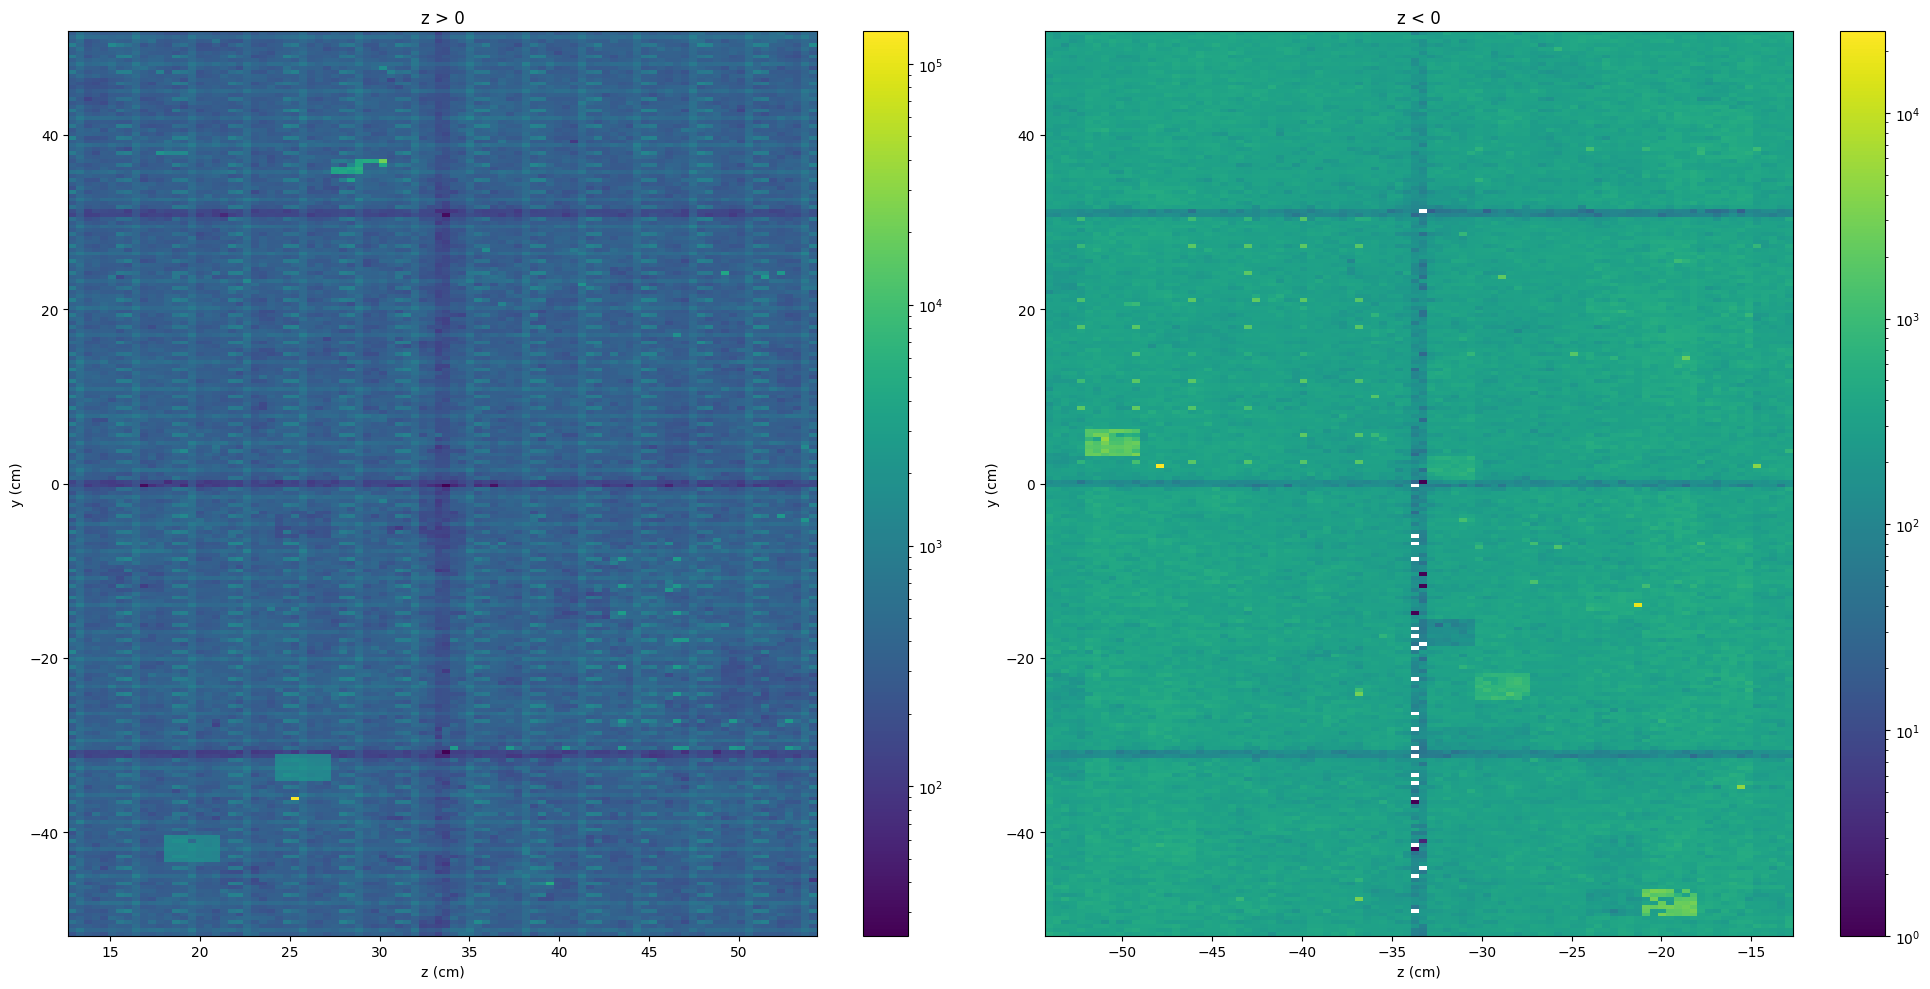

In [45]:

fig, axs = plt.subplots(1, 2, figsize=(20, 10))

# ---- z > 0 ----
h1 = axs[0].hist2d(
    z_2, y_2,
    bins=[94,234],
    range=[[12.68, 54.32], [-51.85, 51.85]],
    norm=LogNorm()
)
plt.colorbar(h1[3], ax=axs[0])
axs[0].set_title("z > 0")
axs[0].set_xlabel("z (cm)")
axs[0].set_ylabel("y (cm)")

# ---- z < 0 ----
h2 = axs[1].hist2d(
    z_1, y_1,
    bins=[94,234],
    range=[[-54.32, -12.68], [-51.85, 51.85]],
    norm=LogNorm()
)
plt.colorbar(h2[3], ax=axs[1])
axs[1].set_title("z < 0")
axs[1].set_xlabel("z (cm)")
axs[1].set_ylabel("y (cm)")

plt.tight_layout()
plt.show()

In [40]:
def find_hot_regions(z, y, hist_range, bins, hot_percentile=99):
    H, z_edges, y_edges = np.histogram2d(z, y, bins=bins, range=hist_range)

    if np.any(H > 0):
        thr = np.percentile(H[H > 0], hot_percentile)
    else:
        thr = np.inf
    hot = (H > thr) 
    visited = np.zeros_like(hot, dtype=bool)
    regions = []
    nz, ny = hot.shape

    for i in range(nz):
        for j in range(ny):
            if not hot[i, j] or visited[i, j]:
                continue

            # flood fill / BFS
            stack = [(i, j)]
            visited[i, j] = True
            cells = []

            while stack:
                x, yy = stack.pop()
                cells.append((x, yy))

                for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
                    xn, yn = x + dx, yy + dy
                    if 0 <= xn < nz and 0 <= yn < ny:
                        if hot[xn, yn] and not visited[xn, yn]:
                            visited[xn, yn] = True
                            stack.append((xn, yn))

            iz = [c[0] for c in cells]
            iy = [c[1] for c in cells]
            
            region = {
                "z_range": (z_edges[min(iz)], z_edges[max(iz) + 1]),
                "y_range": (y_edges[min(iy)], y_edges[max(iy) + 1]),
                "n_bins": len(cells),
                "count_sum": int(sum(H[a, b] for a, b in cells))
            }
            regions.append(region)
    regions = [
        r for r in regions
        if (r["n_bins"] >= 10) or (r["count_sum"] >= 20000)
        ]

    regions.sort(key=lambda r: r["count_sum"], reverse=True)
    return H, z_edges, y_edges, hot, regions


In [41]:
def remove_regions(z, y, regions):
    keep = np.ones(len(z), dtype=bool)
    for r in regions:
        zmin, zmax = r["z_range"]
        ymin, ymax = r["y_range"]
        inside = (z >= zmin) & (z < zmax) & (y >= ymin) & (y < ymax)
        keep &= ~inside
    return z[keep], y[keep]

In [51]:
bins = [94, 234]
range_pos = [[12.68, 54.32], [-51.85, 51.85]]
range_neg = [[-54.32, -12.68], [-51.85, 51.85]]
H_pos, z_edges_pos, y_edges_pos, hot_pos, regions_pos = find_hot_regions(
    z_2, y_2, range_pos, bins,
    hot_percentile=95
    
)

H_neg, z_edges_neg, y_edges_neg, hot_neg, regions_neg = find_hot_regions(
    z_1, y_1, range_neg, bins,
    hot_percentile=99
)

In [52]:
print("\nHot regions for z > 0:")
for i, r in enumerate(regions_pos, 1):
    print(
        f"{i}: z = [{r['z_range'][0]:.2f}, {r['z_range'][1]:.2f}], "
        f"y = [{r['y_range'][0]:.2f}, {r['y_range'][1]:.2f}], "
        f"n_bins = {r['n_bins']}, count_sum = {r['count_sum']}"
    )

print("\nHot regions for z < 0:")
for i, r in enumerate(regions_neg, 1):
    print(
        f"{i}: z = [{r['z_range'][0]:.2f}, {r['z_range'][1]:.2f}], "
        f"y = [{r['y_range'][0]:.2f}, {r['y_range'][1]:.2f}], "
        f"n_bins = {r['n_bins']}, count_sum = {r['count_sum']}"
    )


Hot regions for z > 0:
1: z = [25.08, 25.53], y = [-36.34, -35.90], n_bins = 1, count_sum = 136325
2: z = [27.30, 30.40], y = [35.45, 37.23], n_bins = 15, count_sum = 77218
3: z = [24.20, 27.30], y = [-34.12, -31.02], n_bins = 49, count_sum = 66379
4: z = [18.00, 21.10], y = [-43.43, -40.33], n_bins = 48, count_sum = 64985

Hot regions for z < 0:
1: z = [-52.11, -49.00], y = [3.10, 6.20], n_bins = 45, count_sum = 89074
2: z = [-21.10, -18.00], y = [-49.63, -46.53], n_bins = 36, count_sum = 80626
3: z = [-30.40, -27.30], y = [-24.82, -21.71], n_bins = 41, count_sum = 33615
4: z = [-48.12, -47.68], y = [1.77, 2.22], n_bins = 1, count_sum = 24885


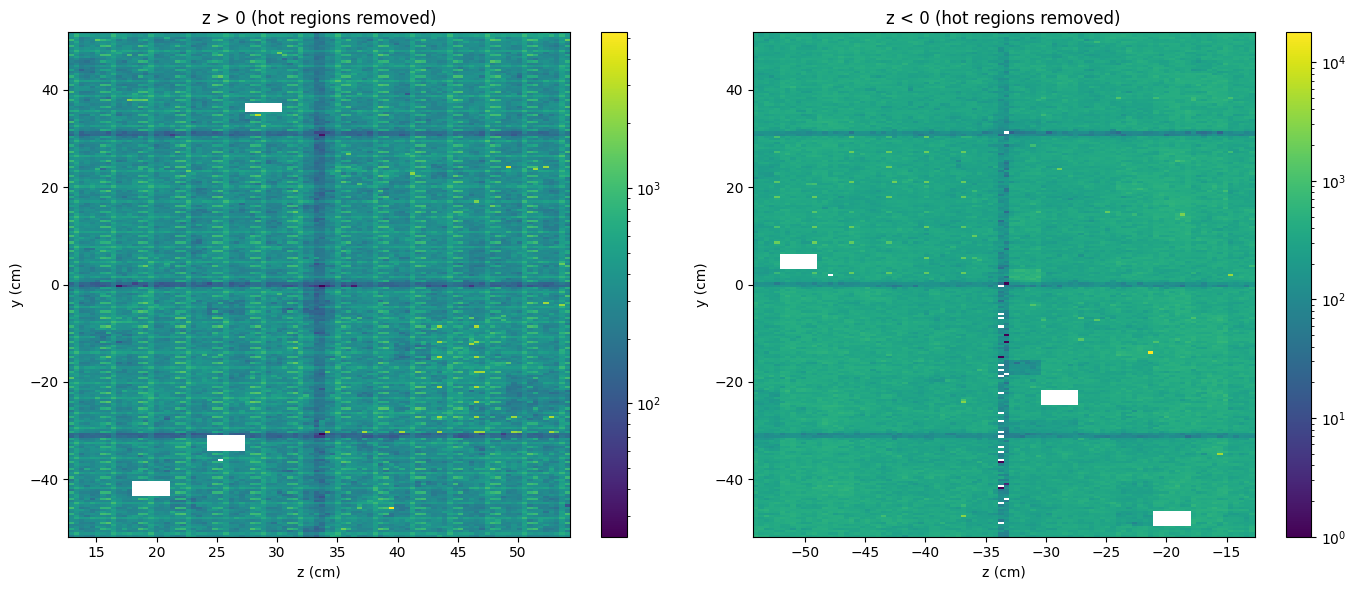

In [53]:
# -------------------------
# remove hot regions
# -------------------------
z_pos_clean, y_pos_clean = remove_regions(z_2, y_2, regions_pos)
z_neg_clean, y_neg_clean = remove_regions(z_1, y_1, regions_neg)

# -------------------------
# plot cleaned maps
# -------------------------
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

h1 = axs[0].hist2d(
    z_pos_clean, y_pos_clean,
    bins=bins, range=range_pos, norm=LogNorm()
)
plt.colorbar(h1[3], ax=axs[0])
axs[0].set_title("z > 0 (hot regions removed)")
axs[0].set_xlabel("z (cm)")
axs[0].set_ylabel("y (cm)")

h2 = axs[1].hist2d(
    z_neg_clean, y_neg_clean,
    bins=bins, range=range_neg, norm=LogNorm()
)
plt.colorbar(h2[3], ax=axs[1])
axs[1].set_title("z < 0 (hot regions removed)")
axs[1].set_xlabel("z (cm)")
axs[1].set_ylabel("y (cm)")

plt.tight_layout()
plt.show()

In [5]:
min_dist = 10.0  
only1 = 0
only2 = 0
other = 0
total = 0

with h5py.File("dbscan_results.h5", "r") as f:
    for key in f["events"]:
        g = f["events"][key]

        labels = g["labels"][:]
        x = g["x"][:]
        y = g["y"][:]
        z = g["z"][:]

        geom_mask = (
            (y >= -51.85) & (y <= 51.85) &
            (((z >= 12.68) & (z <= 54.32)) | ((z >= -54.32) & (z <= -12.68)))
        )

        idx = np.where(geom_mask & (labels >= 0))[0]
        if idx.size == 0:
            continue

        uniq = np.unique(labels[idx])
        nlab = uniq.size

        total += 1
        if nlab == 1:
            only1 += 1
        elif nlab == 2:
            only2 += 1
        else:
            other += 1

print("Total events with >=1 clustered hit in geom:", total)
print("Events with exactly 1 label:", only1)
print("Events with exactly 2 labels:", only2)
print("Events with >=3 labels:", other)

Total events with >=1 clustered hit in geom: 38684
Events with exactly 1 label: 31419
Events with exactly 2 labels: 3633
Events with >=3 labels: 3632
